Conditional GANs


Generating FACES on given prompt male or female 

In [1]:
import torch
import torch.nn as nn


In [5]:
#reshape class
class Reshape(nn.Module):
    def __init__(self, *shape):
        super().__init__()
        self.shape = shape

    def forward(self, x):
        return x.view(x.size(0), *self.shape)
    
#generator of cGAN
class Generator(nn.Module):

    def __init__(self,z_size=100,img_channels=3):
        super().__init__()

        self.Embedding = nn.Embedding(2,100)
        self.model = nn.Sequential(
            nn.Linear(200,8192),
            Reshape(128,8,8),
            nn.ConvTranspose2d(128, 128, 4, 2, 1),  # 8 → 16
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 128, 4, 2, 1),  # 16 → 32
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 32 → 64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 3, 1, 1),    # keep 64×64, reduce channels
            nn.Tanh()  # very important for GAN output
        )

    def forward(self,x,labels):
        embed = self.Embedding(labels)
        x = torch.cat([x,embed],dim=1)
        img = self.model(x)
        #img = img.view(img.size(0),3,64,64)
        return img
    
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.Embedding = nn.Embedding(2,64*64)
        
        self.model = nn.Sequential(

            # (B, 4, 64, 64) → (B, 64, 32, 32)
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # (B, 64, 32, 32) → (B, 128, 16, 16)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # (B, 128, 16, 16) → (B, 256, 8, 8)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # Flatten
            nn.Flatten(),
            # 256 * 8 * 8 = 16384 → 1
            nn.Linear(256 * 8 * 8, 1)
)

    def forward(self,x,labels):
        #adding embedding as Channel 
        B = x.size(0)
        embedd = self.Embedding(labels)
        embedd = embedd.view(B, 1, 64, 64)
        x= torch.cat([x,embedd],dim=1)

        return self.model(x)
    
    
        




In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import os

In [ ]:
class Trainer:
    def __init__(
        self,
        data_path,
        batch_size=32,
        z_dim=100,
        lr=0.0002,
        device=None
    ):
        self.data_path = data_path
        self.batch_size = batch_size
        self.z_dim = z_dim
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")

        # Models
        self.G = Generator(z_dim).to(self.device)
        self.D = Discriminator().to(self.device)

        # Optimizers
        self.opt_G = optim.Adam(self.G.parameters(), lr=lr, betas=(0.5, 0.999))
        self.opt_D = optim.Adam(self.D.parameters(), lr=lr, betas=(0.5, 0.999))

        # loss
        self.criterion = nn.BCEWithLogitsLoss()

        # DataLoader (auto labels)
        self.dataloader = self.get_dataloader()

    def get_dataloader(self):

        transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

        dataset = datasets.ImageFolder(
            root=self.data_path,
            transform=transform
        )

        print("Classes:", dataset.classes) 

        loader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=2
        )

        return loader

    def train(self, epochs=10):

        for epoch in range(epochs):
            loop = tqdm(self.dataloader, leave=True)

            for batch_idx, (real, labels) in enumerate(loop):

                real = real.to(self.device)
                labels = labels.to(self.device).long()
                batch_size = real.size(0)

                noise = torch.randn(batch_size, self.z_dim).to(self.device)

                fake_labels = torch.randint(0, 2, (batch_size,), device=self.device)

                fake = self.G(noise, fake_labels)

                D_real = self.D(real, labels).reshape(-1)
                D_fake = self.D(fake.detach(), fake_labels).reshape(-1)

                loss_D_real = self.criterion(D_real, torch.ones_like(D_real))
                loss_D_fake = self.criterion(D_fake, torch.zeros_like(D_fake))
                loss_D = (loss_D_real + loss_D_fake) / 2

                self.opt_D.zero_grad()
                loss_D.backward()
                self.opt_D.step()

                output = self.D(fake, fake_labels).reshape(-1)
                loss_G = self.criterion(output, torch.ones_like(output))

                self.opt_G.zero_grad()
                loss_G.backward()
                self.opt_G.step()

                loop.set_postfix(
                    loss_D=loss_D.item(),
                    loss_G=loss_G.item()
                )

            print(f"Epoch [{epoch+1}/{epochs}] Done")

In [14]:
trainer = Trainer("/Users/abhishek/Generative-Adversarial-Network/dataset")
trainer.train(1)

Classes: ['class0', 'class1']


100%|██████████| 2/2 [00:12<00:00,  6.01s/it, loss_D=1.13, loss_G=3.27] 

Epoch [1/1] Done


In [16]:
import matplotlib.pyplot as plt
import torchvision

def show_generated_images(G, device, z_dim=100):
    G.eval()

    with torch.no_grad():
        z = torch.randn(16, z_dim).to(device)

        # try both classes
        labels_0 = torch.zeros(16, dtype=torch.long).to(device)
        labels_1 = torch.ones(16, dtype=torch.long).to(device)

        fake_0 = G(z, labels_0)
        fake_1 = G(z, labels_1)

        # Denormalize [-1,1] → [0,1]
        fake_0 = (fake_0 + 1) / 2
        fake_1 = (fake_1 + 1) / 2

        # Make grids
        grid_0 = torchvision.utils.make_grid(fake_0, nrow=4)
        grid_1 = torchvision.utils.make_grid(fake_1, nrow=4)

        # Show images
        plt.figure(figsize=(8,4))

        plt.subplot(1,2,1)
        plt.title("Class 0")
        plt.imshow(grid_0.permute(1,2,0).cpu())
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.title("Class 1")
        plt.imshow(grid_1.permute(1,2,0).cpu())
        plt.axis("off")

        plt.show()

    G.train()

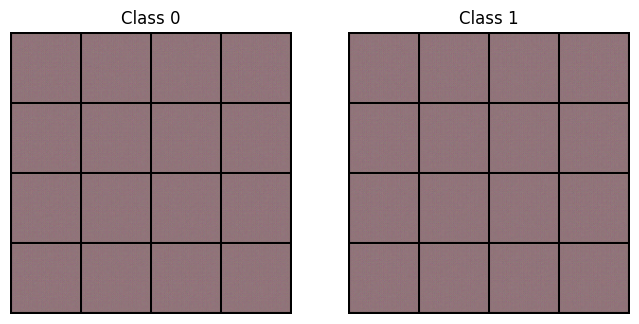

In [17]:
show_generated_images(trainer.G,trainer.device)